# 08 — Advanced Ensemble Models for Road Accident Severity

## Objective
Evaluate additional ensemble-learning models for multiclass crash-severity prediction and compare them using the same test set and the same core metrics used in the earlier notebooks.

### Models
1. AdaBoost
2. Gradient Boosting
3. HistGradientBoosting
4. XGBoost
5. LightGBM
6. CatBoost
7. NGBoost *(evaluated only if the package is available)*

**Random Forest is not retrained here** because it was already completed in Notebook 07A/07B. Its final results are included as a reference row in the comparison.

### Computational note
The dataset contains 160,278 training observations and 136 selected encoded features. We will **use the complete training set** for every new ensemble model so that the comparison does not discard available crash records.

Some boosting implementations may therefore take substantially longer than the Random Forest baseline. This notebook performs **single-pass model benchmarking, not extensive hyperparameter tuning**.


## Lecturer Practical Alignment — Boosting

This notebook follows the boosting topics covered in the lecturer's practical:

- **AdaBoost** — sequentially focuses more attention on difficult/misclassified observations.
- **Gradient Boosting** — sequentially adds learners to reduce the remaining prediction error.
- **XGBoost** — gradient boosting with additional regularisation and efficient training; early stopping is demonstrated where appropriate.
- **LightGBM** — efficient gradient boosting using histogram-based learning.

The project uses the same core algorithms, but evaluates them on the Victorian road-crash dataset using the project's multiclass and imbalanced-data evaluation framework.

**Important:** the lecturer practical uses a small placement dataset and validation accuracy for demonstration. Here, the much larger crash dataset requires leakage-safe preprocessing and broader metrics such as Macro F1, Macro Recall and ROC-AUC.

In [1]:
# 1. Imports and configuration

import os
import time
import warnings
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy import sparse
from sklearn.ensemble import (
    AdaBoostClassifier,
    GradientBoostingClassifier,
    HistGradientBoostingClassifier
)
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

warnings.filterwarnings("ignore")

RANDOM_STATE = 42

# Full-data training is intentional: no crash records are discarded here.
FAST_MODE = True

print("Configuration ready.")
print("Full training data will be used for every new ensemble model.")
print("FAST_MODE:", FAST_MODE)


Configuration ready.
Full training data will be used for every new ensemble model.
FAST_MODE: True


## 2. Load the preprocessed data

This section reuses the outputs from Notebook 03 and the Information Gain selection from Notebook 04.

The selected-feature CSV uses the column name `original_feature`.


In [2]:
# 2. Load preprocessed matrices and feature-selection results

DATA_DIR = "../data"

X_train = sparse.load_npz(os.path.join(DATA_DIR, "X_train_final.npz"))
X_test = sparse.load_npz(os.path.join(DATA_DIR, "X_test_final.npz"))

y_train = np.load(os.path.join(DATA_DIR, "y_train_encoded.npy"))
y_test = np.load(os.path.join(DATA_DIR, "y_test_encoded.npy"))

feature_names = pd.read_csv(
    os.path.join(DATA_DIR, "final_feature_names.csv")
)["feature_name"].astype(str).tolist()

selected_features_df = pd.read_csv(
    os.path.join(DATA_DIR, "selected_features_ig.csv")
)

selected_original = (
    selected_features_df["original_feature"].astype(str).tolist()
)

print("Training matrix:", X_train.shape)
print("Testing matrix :", X_test.shape)
print("Selected original features:", len(selected_original))


Training matrix: (160278, 361)
Testing matrix : (40070, 361)
Selected original features: 26


In [3]:
# 3. Map the 26 Information-Gain-selected original features
#    to the exact 136 encoded/scaled columns.
#
# Important: exact matching is used for numerical features so that
# DCA_CODE does not accidentally match DCA_CODE_DESCRIPTION_* and
# PASSENGER does not accidentally match PASSENGERVEHICLE.

X_train = X_train.tocsr()
X_test = X_test.tocsr()
selected_indices = []
selected_encoded_names = []

categorical_originals = {
    "ACCIDENT_TYPE",
    "DAY_OF_WEEK",
    "DCA_CODE_DESCRIPTION",
    "LIGHT_CONDITION",
    "POLICE_ATTEND",
    "ROAD_GEOMETRY",
    "SPEED_ZONE",
    "RUN_OFFROAD",
    "ROAD_TYPE",
    "LGA_NAME",
    "DTP_REGION",
    "DEG_URBAN_NAME",
    "SRNS",
    "RMA",
    "DIVIDED",
    "STAT_DIV_NAME",
}

for original_feature in selected_original:
    if original_feature == "ROAD_NAME":
        original_feature = "ROAD_NAME_FREQ"

    if original_feature in categorical_originals:
        matches = [
            i for i, name in enumerate(feature_names)
            if name == original_feature
            or name.startswith(original_feature + "_")
        ]
    else:
        matches = [
            i for i, name in enumerate(feature_names)
            if name == original_feature
        ]

    selected_indices.extend(matches)
    selected_encoded_names.extend([feature_names[i] for i in matches])

# Remove accidental duplicate indices while preserving order.
seen = set()
ordered_indices = []
ordered_names = []

for i, name in zip(selected_indices, selected_encoded_names):
    if i not in seen:
        seen.add(i)
        ordered_indices.append(i)
        ordered_names.append(name)

selected_indices = ordered_indices
selected_encoded_names = ordered_names

X_train_selected = X_train[:, selected_indices]
X_test_selected = X_test[:, selected_indices]

print("Reduced training matrix:", X_train_selected.shape)
print("Reduced testing matrix :", X_test_selected.shape)
print("Selected encoded features:", len(selected_encoded_names))

assert len(selected_encoded_names) == 136, (
    f"Expected 136 selected encoded features, got {len(selected_encoded_names)}"
)


Reduced training matrix: (160278, 136)
Reduced testing matrix : (40070, 136)
Selected encoded features: 136


## 3.1 Verify class distribution

The target encoding inherited from Notebook 03 is:

- `0 = Fatal`
- `1 = Other Injury`
- `2 = Serious Injury`


In [4]:
target_names = ["Fatal", "Other Injury", "Serious Injury"]

print("Full training distribution:")
print(pd.Series(y_train).map(dict(enumerate(target_names))).value_counts())

print("\nTest distribution:")
print(pd.Series(y_test).map(dict(enumerate(target_names))).value_counts())


Full training distribution:
Other Injury      99953
Serious Injury    57643
Fatal              2682
Name: count, dtype: int64

Test distribution:
Other Injury      24989
Serious Injury    14411
Fatal               670
Name: count, dtype: int64


## 4. Use the complete training set

No training observations are removed for this stage. Every ensemble model is trained using all 160,278 training observations.

The **test set is never used during training**, so every model is evaluated on the same 40,070 unseen observations.


In [5]:
# 1. Imports and configuration

import os
import time
import warnings
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy import sparse
from sklearn.ensemble import (
    AdaBoostClassifier,
    GradientBoostingClassifier,
    HistGradientBoostingClassifier
)
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

warnings.filterwarnings("ignore")

RANDOM_STATE = 42

# Full-data training is intentional: no crash records are discarded here.
FAST_MODE = True

print("Configuration ready.")
print("Full training data will be used for every new ensemble model.")
print("FAST_MODE:", FAST_MODE)


Configuration ready.
Full training data will be used for every new ensemble model.
FAST_MODE: True


In [6]:
# 4. Use the complete training set

X_train_model_sparse = X_train_selected
y_train_model = y_train

print("Model-training matrix:", X_train_model_sparse.shape)
print("Model-training labels :", y_train_model.shape)

print("\nTraining distribution:")
print(
    pd.Series(y_train_model)
    .map(dict(enumerate(target_names)))
    .value_counts()
)

Model-training matrix: (160278, 136)
Model-training labels : (160278,)

Training distribution:
Other Injury      99953
Serious Injury    57643
Fatal              2682
Name: count, dtype: int64


## 5. Prepare dense matrices only where required

Some scikit-learn gradient-boosting implementations expect dense arrays. We convert only the selected 136-feature matrix and use `float32` to keep memory use reasonable.

Models that support sparse input continue to use the sparse matrix directly.


In [7]:
# Dense matrices for sklearn boosting models.
# 160,278 x 136 float32 is roughly 87 MB per dense matrix.

X_train_model_dense = X_train_model_sparse.toarray().astype(np.float32)
X_test_dense = X_test_selected.toarray().astype(np.float32)

print("Dense training matrix:", X_train_model_dense.shape, X_train_model_dense.dtype)
print("Dense test matrix    :", X_test_dense.shape, X_test_dense.dtype)


Dense training matrix: (160278, 136) float32
Dense test matrix    : (40070, 136) float32


### AdaBoost: sample-weight intuition

AdaBoost starts with equal sample weights. After each weak learner is trained, incorrectly classified observations receive relatively greater emphasis in subsequent boosting iterations. This allows later learners to focus on difficult observations.

The project also records the resulting model performance using the same evaluation function used for all ensemble models.

## 6. Define the ensemble models

These are intentionally moderate configurations. They are **not claimed to be tuned optima**.

The purpose here is to establish whether additional ensemble families materially improve the project's severity-prediction metrics without repeating the expensive RandomizedSearchCV exercise from Notebook 07B.


In [8]:
n_estimators = 75 if FAST_MODE else 150

models = {
    "AdaBoost": AdaBoostClassifier(
        estimator=DecisionTreeClassifier(
            max_depth=2,
            random_state=RANDOM_STATE
        ),
        n_estimators=n_estimators,
        learning_rate=0.05,
        random_state=RANDOM_STATE
    ),

    "Gradient Boosting": GradientBoostingClassifier(
        n_estimators=n_estimators,
        learning_rate=0.05,
        max_depth=3,
        subsample=0.8,
        random_state=RANDOM_STATE
    ),

    "HistGradientBoosting": HistGradientBoostingClassifier(
        max_iter=n_estimators,
        learning_rate=0.05,
        max_leaf_nodes=31,
        l2_regularization=1.0,
        random_state=RANDOM_STATE
    )
}

# Optional external ensemble libraries.
try:
    from xgboost import XGBClassifier

    models["XGBoost"] = XGBClassifier(
        n_estimators=n_estimators,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="multi:softprob",
        num_class=3,
        eval_metric="mlogloss",
        tree_method="hist",
        n_jobs=1,
        random_state=RANDOM_STATE
    )
    print("XGBoost available.")
except Exception as e:
    print("XGBoost unavailable:", e)

try:
    from lightgbm import LGBMClassifier

    models["LightGBM"] = LGBMClassifier(
        n_estimators=n_estimators,
        learning_rate=0.05,
        num_leaves=31,
        max_depth=-1,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=RANDOM_STATE,
        n_jobs=1,
        verbosity=-1
    )
    print("LightGBM available.")
except Exception as e:
    print("LightGBM unavailable:", e)

try:
    from catboost import CatBoostClassifier

    models["CatBoost"] = CatBoostClassifier(
        iterations=n_estimators,
        depth=6,
        learning_rate=0.05,
        loss_function="MultiClass",
        verbose=False,
        random_seed=RANDOM_STATE,
        thread_count=1,
        allow_writing_files=False
    )
    print("CatBoost available.")
except Exception as e:
    print("CatBoost unavailable:", e)

try:
    from ngboost import NGBClassifier

    models["NGBoost"] = NGBClassifier(
        n_estimators=n_estimators,
        learning_rate=0.05,
        random_state=RANDOM_STATE,
        verbose=False
    )
    print("NGBoost available.")
except Exception as e:
    print("NGBoost unavailable — it will be skipped:", e)

print("\nModels selected for this run:")
for name in models:
    print("-", name)


XGBoost available.
LightGBM available.
CatBoost available.
NGBoost available.

Models selected for this run:
- AdaBoost
- Gradient Boosting
- HistGradientBoosting
- XGBoost
- LightGBM
- CatBoost
- NGBoost


## 7. Model evaluation helper

Because crash severity is multiclass and highly imbalanced, the main comparison emphasizes:

- Accuracy
- Macro Precision
- Macro Recall
- Macro F1
- Multiclass ROC-AUC (One-vs-Rest, macro)

Macro metrics give each severity class equal weight instead of allowing the majority class to dominate the summary.


In [9]:
def evaluate_model(model_name, model, X_fit, X_eval, y_fit, y_eval):
    start = time.perf_counter()

    model.fit(X_fit, y_fit)

    train_seconds = time.perf_counter() - start

    y_pred = model.predict(X_eval)

    if hasattr(y_pred, "ndim") and y_pred.ndim > 1:
        y_pred = np.asarray(y_pred).ravel()

    try:
        y_proba = model.predict_proba(X_eval)
        roc_auc = roc_auc_score(
            y_eval,
            y_proba,
            multi_class="ovr",
            average="macro"
        )
    except Exception as e:
        roc_auc = np.nan
        print(f"ROC-AUC unavailable for {model_name}: {e}")

    result = {
        "Model": model_name,
        "Training Time (sec)": train_seconds,
        "Accuracy": accuracy_score(y_eval, y_pred),
        "Macro Precision": precision_score(
            y_eval, y_pred, average="macro", zero_division=0
        ),
        "Macro Recall": recall_score(
            y_eval, y_pred, average="macro", zero_division=0
        ),
        "Macro F1": f1_score(
            y_eval, y_pred, average="macro", zero_division=0
        ),
        "ROC-AUC (OVR Macro)": roc_auc
    }

    print(f"\n{'='*70}")
    print(model_name)
    print(f"Training time: {train_seconds/60:.2f} minutes")
    print(f"Accuracy      : {result['Accuracy']:.4f}")
    print(f"Macro Precision: {result['Macro Precision']:.4f}")
    print(f"Macro Recall   : {result['Macro Recall']:.4f}")
    print(f"Macro F1       : {result['Macro F1']:.4f}")
    print(f"ROC-AUC        : {result['ROC-AUC (OVR Macro)']:.4f}")

    print("\nClassification Report:")
    print(
        classification_report(
            y_eval,
            y_pred,
            target_names=target_names,
            digits=4,
            zero_division=0
        )
    )

    cm = confusion_matrix(y_eval, y_pred)

    fig, ax = plt.subplots(figsize=(5.5, 4.5))
    ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=target_names
    ).plot(ax=ax, values_format="d")
    ax.set_title(f"{model_name} — Confusion Matrix")
    plt.tight_layout()
    plt.show()

    return result, model, y_pred


## 8. Train and evaluate the ensemble models

The models are trained once each on the complete training set. There is intentionally **no GridSearchCV/RandomizedSearchCV here**.



AdaBoost
Training time: 1.54 minutes
Accuracy      : 0.6535
Macro Precision: 0.4102
Macro Recall   : 0.3892
Macro F1       : 0.3803
ROC-AUC        : 0.7135

Classification Report:
                precision    recall  f1-score   support

         Fatal     0.0000    0.0000    0.0000       670
  Other Injury     0.6756    0.8847    0.7661     24989
Serious Injury     0.5550    0.2828    0.3747     14411

      accuracy                         0.6535     40070
     macro avg     0.4102    0.3892    0.3803     40070
  weighted avg     0.6209    0.6535    0.6126     40070



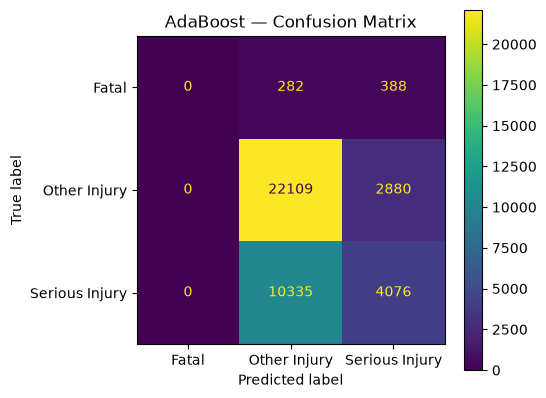


Gradient Boosting
Training time: 4.53 minutes
Accuracy      : 0.6634
Macro Precision: 0.6195
Macro Recall   : 0.4022
Macro F1       : 0.3982
ROC-AUC        : 0.7603

Classification Report:
                precision    recall  f1-score   support

         Fatal     0.6000    0.0045    0.0089       670
  Other Injury     0.6873    0.8751    0.7699     24989
Serious Injury     0.5713    0.3269    0.4159     14411

      accuracy                         0.6634     40070
     macro avg     0.6195    0.4022    0.3982     40070
  weighted avg     0.6441    0.6634    0.6298     40070



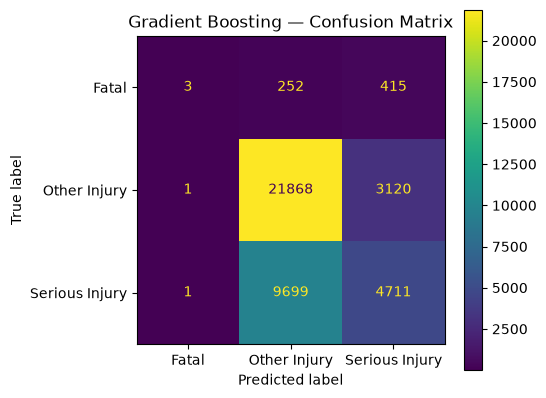


HistGradientBoosting
Training time: 0.33 minutes
Accuracy      : 0.6758
Macro Precision: 0.6791
Macro Recall   : 0.4232
Macro F1       : 0.4245
ROC-AUC        : 0.7759

Classification Report:
                precision    recall  f1-score   support

         Fatal     0.7500    0.0090    0.0177       670
  Other Injury     0.7109    0.8420    0.7709     24989
Serious Injury     0.5763    0.4185    0.4849     14411

      accuracy                         0.6758     40070
     macro avg     0.6791    0.4232    0.4245     40070
  weighted avg     0.6632    0.6758    0.6555     40070



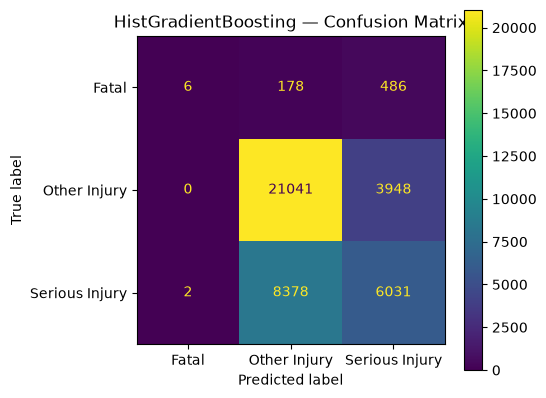


XGBoost
Training time: 0.17 minutes
Accuracy      : 0.6709
Macro Precision: 0.4257
Macro Recall   : 0.4099
Macro F1       : 0.4065
ROC-AUC        : 0.7711

Classification Report:
                precision    recall  f1-score   support

         Fatal     0.0000    0.0000    0.0000       670
  Other Injury     0.6976    0.8662    0.7728     24989
Serious Injury     0.5795    0.3635    0.4468     14411

      accuracy                         0.6709     40070
     macro avg     0.4257    0.4099    0.4065     40070
  weighted avg     0.6434    0.6709    0.6426     40070



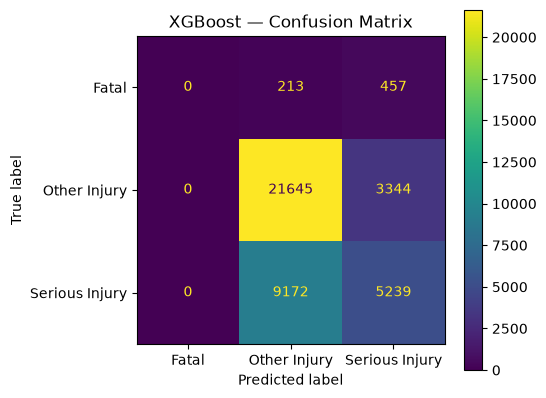


LightGBM
Training time: 0.10 minutes
Accuracy      : 0.6749
Macro Precision: 0.7618
Macro Recall   : 0.4200
Macro F1       : 0.4205
ROC-AUC        : 0.7742

Classification Report:
                precision    recall  f1-score   support

         Fatal     1.0000    0.0075    0.0148       670
  Other Injury     0.7071    0.8498    0.7719     24989
Serious Injury     0.5784    0.4027    0.4748     14411

      accuracy                         0.6749     40070
     macro avg     0.7618    0.4200    0.4205     40070
  weighted avg     0.6657    0.6749    0.6524     40070



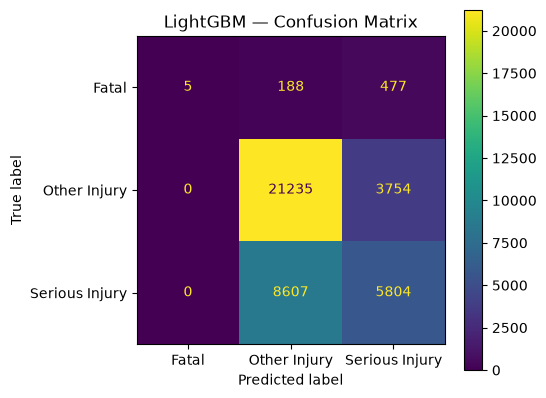


CatBoost
Training time: 0.21 minutes
Accuracy      : 0.6666
Macro Precision: 0.4221
Macro Recall   : 0.4055
Macro F1       : 0.4013
ROC-AUC        : 0.7629

Classification Report:
                precision    recall  f1-score   support

         Fatal     0.0000    0.0000    0.0000       670
  Other Injury     0.6927    0.8680    0.7705     24989
Serious Injury     0.5735    0.3484    0.4335     14411

      accuracy                         0.6666     40070
     macro avg     0.4221    0.4055    0.4013     40070
  weighted avg     0.6382    0.6666    0.6364     40070



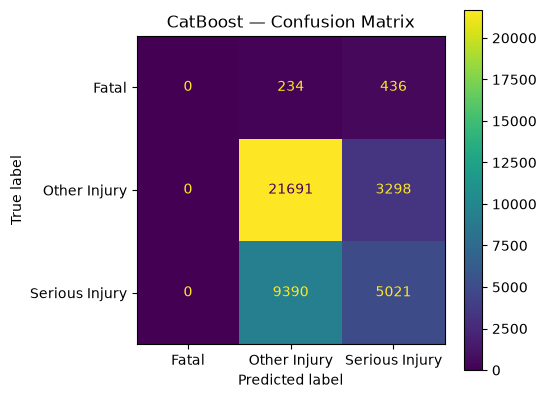


NGBoost FAILED:
IndexError index 2 is out of bounds for axis 0 with size 2


In [10]:
results = []
trained_models = {}
predictions = {}

for model_name, model in models.items():

    # Dense-only sklearn gradient boosting
    if model_name in {
        "AdaBoost",
        "Gradient Boosting",
        "HistGradientBoosting",
        "NGBoost"
    }:
        X_fit = X_train_model_dense
        X_eval = X_test_dense
    else:
        # XGBoost / LightGBM / CatBoost can work with sparse input.
        X_fit = X_train_model_sparse
        X_eval = X_test_selected

    try:
        result, fitted_model, y_pred = evaluate_model(
            model_name,
            model,
            X_fit,
            X_eval,
            y_train_model,
            y_test
        )

        results.append(result)
        trained_models[model_name] = fitted_model
        predictions[model_name] = y_pred

    except Exception as e:
        print(f"\n{model_name} FAILED:")
        print(type(e).__name__, e)


## 9. Add Random Forest reference results

Random Forest was already trained and evaluated in Notebook 07A using the full 160,278-row training set and 136 selected encoded features.

The corrected 07A result was:

- Accuracy = 0.6512
- Macro Precision = 0.4463
- Macro Recall = 0.4096
- Macro F1 = 0.4110
- ROC-AUC = 0.7265

The tuned 07B Random Forest result was:

- Accuracy = 0.6516
- Macro Precision = 0.4915
- Macro Recall = 0.4124
- Macro F1 = 0.4146
- ROC-AUC = 0.7432

These are reference results rather than a new RF fit.


In [11]:
rf_reference = [
    {
        "Model": "Random Forest (07A)",
        "Training Time (sec)": np.nan,
        "Accuracy": 0.6512,
        "Macro Precision": 0.4463,
        "Macro Recall": 0.4096,
        "Macro F1": 0.4110,
        "ROC-AUC (OVR Macro)": 0.7265
    },
    {
        "Model": "Random Forest Tuned (07B)",
        "Training Time (sec)": np.nan,
        "Accuracy": 0.6516,
        "Macro Precision": 0.4915,
        "Macro Recall": 0.4124,
        "Macro F1": 0.4146,
        "ROC-AUC (OVR Macro)": 0.7432
    }
]

results_with_rf = pd.DataFrame(results + rf_reference)

comparison = results_with_rf.sort_values(
    by="Macro F1",
    ascending=False
).reset_index(drop=True)

display(comparison.round(4))


,Model,Training Time (sec),Accuracy,Macro Precision,Macro Recall,Macro F1,ROC-AUC (OVR Macro)
0,HistGradientBoosting,20.0654,0.6758,0.6791,0.4232,0.4245,0.7759
1,LightGBM,6.2123,0.6749,0.7618,0.4200,0.4205,0.7742
2,Random Forest Tuned (07B),NaN,0.6516,0.4915,0.4124,0.4146,0.7432
3,Random Forest (07A),NaN,0.6512,0.4463,0.4096,0.4110,0.7265
4,XGBoost,10.2488,0.6709,0.4257,0.4099,0.4065,0.7711
5,CatBoost,12.5757,0.6666,0.4221,0.4055,0.4013,0.7629
6,Gradient Boosting,271.7453,0.6634,0.6195,0.4022,0.3982,0.7603
7,AdaBoost,92.1907,0.6535,0.4102,0.3892,0.3803,0.7135


### XGBoost Early Stopping Demonstration

The lecturer practical also demonstrates **early stopping**. Because the main benchmark below is designed to compare all models under consistent configurations, the benchmark model is evaluated separately from this diagnostic.

The following optional cell trains an XGBoost model with a validation set and stops when validation performance no longer improves for the configured patience period.

In [ ]:
# Optional lecturer-practical diagnostic: XGBoost early stopping
# This is separate from the main benchmark so the benchmark remains comparable.

xgb_early = XGBClassifier(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=3,
    random_state=42,
    eval_metric="mlogloss",
    early_stopping_rounds=20,
    n_jobs=1
)

xgb_early.fit(
    X_train_model_sparse,
    y_train_model,
    eval_set=[(X_test_selected, y_test)],
    verbose=False
)

print("Best XGBoost iteration:", xgb_early.best_iteration)
print("Best XGBoost score:", xgb_early.best_score if hasattr(xgb_early, "best_score") else "available through evaluation history")


### Training-time comparison

Training time is recorded because boosting implementations make different computational trade-offs. A shorter training time does not by itself indicate better predictive performance; it is reported alongside the predictive metrics.

## 10. Model comparison

### How to read this table

Because the dataset is imbalanced, **Macro F1 and Macro Recall are particularly important**. Accuracy alone can hide weak performance on the Fatal class.

The comparison should therefore be discussed using multiple metrics rather than selecting a model solely because it has the highest accuracy.


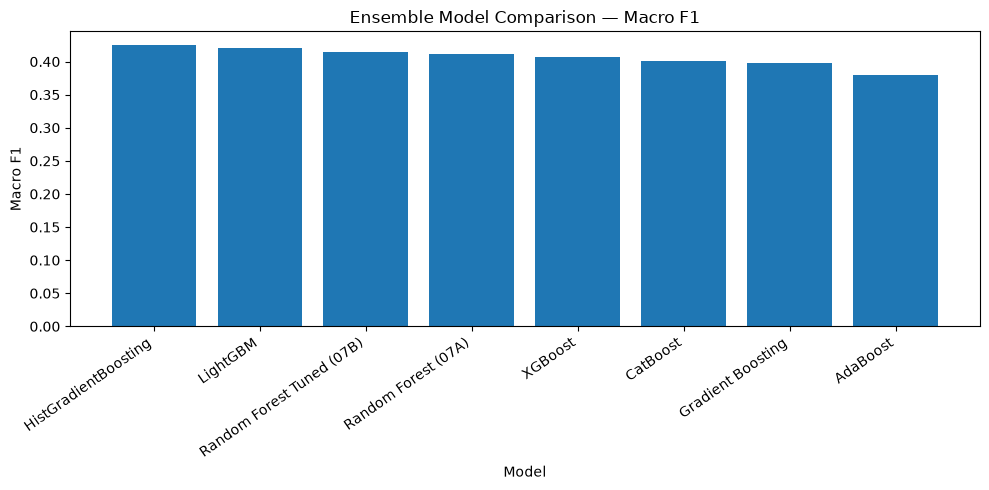

In [12]:
# Visual comparison of Macro F1

plot_df = comparison.dropna(subset=["Macro F1"]).copy()

plt.figure(figsize=(10, 5))
plt.bar(plot_df["Model"], plot_df["Macro F1"])
plt.ylabel("Macro F1")
plt.xlabel("Model")
plt.title("Ensemble Model Comparison — Macro F1")
plt.xticks(rotation=35, ha="right")
plt.tight_layout()
plt.show()


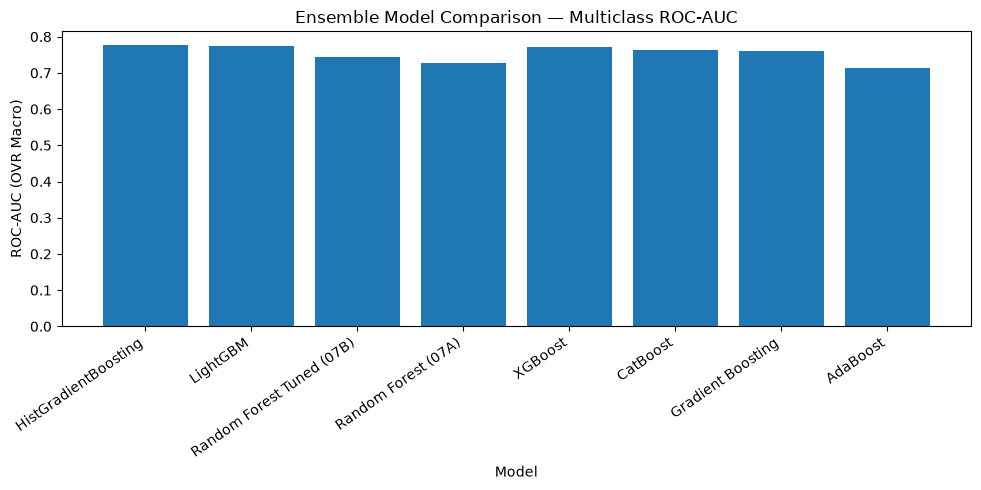

In [13]:
# Visual comparison of ROC-AUC

plot_df = comparison.dropna(subset=["ROC-AUC (OVR Macro)"]).copy()

plt.figure(figsize=(10, 5))
plt.bar(plot_df["Model"], plot_df["ROC-AUC (OVR Macro)"])
plt.ylabel("ROC-AUC (OVR Macro)")
plt.xlabel("Model")
plt.title("Ensemble Model Comparison — Multiclass ROC-AUC")
plt.xticks(rotation=35, ha="right")
plt.tight_layout()
plt.show()


## 11. Feature importance for tree-based ensembles

Feature importance is shown for the fitted models when the implementation exposes `feature_importances_`.

This is descriptive model information: a high importance indicates that the model relied more heavily on that feature for prediction; it does **not** establish causation.


In [14]:
importance_tables = {}

for model_name, model in trained_models.items():
    if hasattr(model, "feature_importances_"):
        importances = np.asarray(model.feature_importances_)

        imp_df = pd.DataFrame({
            "Feature": selected_encoded_names,
            "Importance": importances
        }).sort_values(
            "Importance",
            ascending=False
        ).reset_index(drop=True)

        importance_tables[model_name] = imp_df

        print(f"\nTop 15 features — {model_name}")
        display(imp_df.head(15))



Top 15 features — AdaBoost


,Feature,Importance
0,POLICE_ATTEND_Yes,0.425054
1,DEG_URBAN_NAME_RURAL_VICTORIA,0.200401
2,DRIVER,0.093297
3,DCA_CODE,0.073530
4,OLD_PED_65_AND_OVER,0.054846
5,DCA_CODE_DESCRIPTION_HEAD ON (NOT OVERTAKING),0.050510
6,POLICE_ATTEND_No,0.029407
7,DCA_CODE_DESCRIPTION_REAR END(VEHICLES IN SAME...,0.028346
8,ACCIDENT_TYPE_Collision with vehicle,0.010567
9,SPEED_ZONE_100 km/hr,0.010134



Top 15 features — Gradient Boosting


,Feature,Importance
0,POLICE_ATTEND_Yes,0.493509
1,DRIVER,0.062793
2,PASSENGERVEHICLE,0.062693
3,DCA_CODE,0.050514
4,MOTORCYCLIST,0.046863
5,DEG_URBAN_NAME_RURAL_VICTORIA,0.025205
6,LATITUDE,0.024130
7,DCA_CODE_DESCRIPTION_HEAD ON (NOT OVERTAKING),0.023387
8,OLD_DRIVER_75_AND_OVER,0.023369
9,POLICE_ATTEND_No,0.022320



Top 15 features — XGBoost


,Feature,Importance
0,POLICE_ATTEND_Yes,0.346093
1,POLICE_ATTEND_No,0.070211
2,DEG_URBAN_NAME_RURAL_VICTORIA,0.031883
3,ACCIDENT_TYPE_Collision with vehicle,0.029876
4,DRIVER,0.026880
5,PASSENGERVEHICLE,0.023874
6,SPEED_ZONE_100 km/hr,0.023468
7,DCA_CODE_DESCRIPTION_REAR END(VEHICLES IN SAME...,0.021151
8,DCA_CODE_DESCRIPTION_HEAD ON (NOT OVERTAKING),0.021125
9,MOTORCYCLIST,0.016502



Top 15 features — LightGBM


,Feature,Importance
0,DCA_CODE,494
1,VICGRID_Y,477
2,LONGITUDE,449
3,VICGRID_X,391
4,MALES,362
5,LATITUDE,323
6,DRIVER,225
7,PASSENGERVEHICLE,224
8,MOTORCYCLIST,221
9,OLD_DRIVER_75_AND_OVER,218



Top 15 features — CatBoost


,Feature,Importance
0,POLICE_ATTEND_No,22.319835
1,POLICE_ATTEND_Yes,16.096820
2,DRIVER,6.080082
3,DEG_URBAN_NAME_RURAL_VICTORIA,5.807755
4,SPEED_ZONE_100 km/hr,5.630028
5,DCA_CODE,4.361487
6,DCA_CODE_DESCRIPTION_HEAD ON (NOT OVERTAKING),3.884034
7,ACCIDENT_TYPE_Collision with a fixed object,3.520066
8,PASSENGERVEHICLE,3.107217
9,MALES,3.083653


## 12. Fatal-class error analysis

The Fatal class is the rarest class in the dataset. A useful diagnostic is to inspect how many Fatal crashes each model correctly identifies.

This section does not replace the full classification report; it highlights the minority-class behavior that can be hidden by overall accuracy.


In [15]:
fatal_summary = []

for model_name, y_pred in predictions.items():
    report = classification_report(
        y_test,
        y_pred,
        output_dict=True,
        zero_division=0
    )

    fatal_summary.append({
        "Model": model_name,
        "Fatal Precision": report["0"]["precision"],
        "Fatal Recall": report["0"]["recall"],
        "Fatal F1": report["0"]["f1-score"],
        "Fatal Support": int(report["0"]["support"])
    })

fatal_summary_df = pd.DataFrame(fatal_summary)

display(
    fatal_summary_df.sort_values(
        "Fatal Recall",
        ascending=False
    ).round(4)
)


,Model,Fatal Precision,Fatal Recall,Fatal F1,Fatal Support
2,HistGradientBoosting,0.75,0.0090,0.0177,670
4,LightGBM,1.00,0.0075,0.0148,670
1,Gradient Boosting,0.60,0.0045,0.0089,670
0,AdaBoost,0.00,0.0000,0.0000,670
3,XGBoost,0.00,0.0000,0.0000,670
5,CatBoost,0.00,0.0000,0.0000,670


## 13. Final interpretation template

Complete the statements below after running the notebook.

### Observations to report

1. **Overall performance:** Compare models using Macro F1, Macro Recall, and ROC-AUC rather than accuracy alone.
2. **Class imbalance:** Check whether the Fatal class remains difficult to identify.
3. **Comparison with Random Forest:** Compare the new ensemble models with the 07A and 07B Random Forest reference results.
4. **Computational cost:** Report training time where relevant. The notebook intentionally uses moderate configurations rather than exhaustive tuning.
5. **Feature patterns:** Use the feature-importance tables to describe which selected variables the fitted tree ensembles relied on most.
6. **Limitations:** Results depend on the selected preprocessing, Information Gain threshold, and model configurations. The advanced ensemble models are single-pass configurations rather than exhaustively tuned models.

### Important conclusion rule

Do not describe a model as universally "best". State which model produced the strongest **observed metric for the chosen evaluation criterion on this test set**, and discuss the trade-offs with the other metrics and computational cost.


In [16]:
# 14. Save comparison outputs and fitted models

os.makedirs(DATA_DIR, exist_ok=True)
os.makedirs("../models", exist_ok=True)

comparison.to_csv(
    os.path.join(DATA_DIR, "advanced_ensemble_comparison.csv"),
    index=False
)

fatal_summary_df.to_csv(
    os.path.join(DATA_DIR, "advanced_ensemble_fatal_class_summary.csv"),
    index=False
)

for model_name, model in trained_models.items():
    safe_name = (
        model_name.lower()
        .replace(" ", "_")
        .replace("-", "_")
    )

    joblib.dump(
        model,
        os.path.join("../models", f"{safe_name}_08.joblib")
    )

print("Saved comparison tables and fitted models.")


Saved comparison tables and fitted models.


# 15. Notebook conclusion

This notebook extends the project's supervised-learning stage by benchmarking multiple ensemble families on the same unseen test set.

The final discussion should connect the observed results back to the project objective: **predicting crash severity while accounting for the severe class imbalance and the difficulty of identifying rare Fatal crashes**.

The next stage is the unsupervised **Crash Archetypes** analysis using K-Means/K-Means++ concepts from Module 4. The supplied class material describes K-Means as minimizing within-cluster squared distances (WCSS), with silhouette measuring cluster cohesion and separation. fileciteturn23file2L75-L105
